# Forecasting and Profiling Crime Patterns Across U.S. States (2010–2024)
### A Machine-Learning Approach to FBI Crime Data

**Student:** Edona Halilaj &nbsp;|&nbsp; **Capstone Project**

This notebook implements the full project pipeline end to end, following the proposal's phases:

1. **Data Acquisition** (Phase 2) — obtain FBI UCR estimated-crime data
2. **Data Cleaning** (Phase 3) — handle the 2013 rape-definition change, the 2021 SRS→NIBRS reporting gap, and counts-vs-rates
3. **Exploratory Data Analysis** (Phase 4) — trends, rankings, regional patterns (RQ1–RQ2)
4. **Feature Engineering** (Phase 5)
5. **Modeling** (Phase 6) — forecasting (RQ3), clustering (RQ4), regression (RQ5)
6. **Evaluation** (Phase 7)


# Task 1: Data Acquisition

## Objective

The objective of this project is to investigate violent crime patterns across U.S. states between
2010 and 2024 and examine how socioeconomic conditions are associated with crime rates.

Unlike the initial version of this project, which relied on randomly generated socioeconomic
variables, this version integrates multiple real-world datasets.

Datasets used:

• FBI Estimated Crimes
• U.S. Census ACS 5-Year Estimates
• (Later) Bureau of Labor Statistics unemployment data

These datasets are merged using State FIPS codes and Year.

This approach creates a richer interdisciplinary dataset while demonstrating real-world
data integration, cleaning, and preprocessing.

In [1]:
# ============================================================
# Crime and Socioeconomic Factors Across U.S. States
# Imports
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import time

Path("data/raw").mkdir(parents=True, exist_ok=True)
Path("data/processed").mkdir(parents=True, exist_ok=True)
Path("outputs").mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)

START_YEAR = 2010
END_YEAR = 2024

In [2]:
# Load FBI estimated crime dataset

fbi = pd.read_csv("/content/estimated_crimes_1979_2024.csv")

print(f"Rows: {len(fbi):,}")
print(f"Columns: {len(fbi.columns)}")

display(fbi.head())

Rows: 2,388
Columns: 15


,year,state_abbr,state_name,population,violent_crime,homicide,rape_legacy,rape_revised,robbery,aggravated_assault,property_crime,burglary,larceny,motor_vehicle_theft,caveats
0,1979,NaN,NaN,220099000,1208030,21460,76390.0,NaN,480700,629480,11041500,3327700,6601000,1112800,NaN
1,1979,AK,Alaska,406000,1994,54,292.0,NaN,445,1203,23193,5616,15076,2501,NaN
2,1979,AL,Alabama,3769000,15578,496,1037.0,NaN,4127,9918,144372,48517,83791,12064,NaN
3,1979,AR,Arkansas,2180000,7984,198,595.0,NaN,1626,5565,70949,21457,45267,4225,NaN
4,1979,AZ,Arizona,2450000,14528,219,1120.0,NaN,4305,8884,177977,48916,116976,12085,NaN


In [3]:
# ----------------------------
# Basic Dataset Overview
# ----------------------------

print("Dataset Shape:")
print(fbi.shape)

print("\nFirst 5 Rows:")
display(fbi.head())

print("\nColumn Names:")
print(fbi.columns.tolist())

print("\nData Types:")
print(fbi.dtypes)

print("\nMissing Values:")
print(fbi.isnull().sum())

Dataset Shape:
(2388, 15)

First 5 Rows:


,year,state_abbr,state_name,population,violent_crime,homicide,rape_legacy,rape_revised,robbery,aggravated_assault,property_crime,burglary,larceny,motor_vehicle_theft,caveats
0,1979,NaN,NaN,220099000,1208030,21460,76390.0,NaN,480700,629480,11041500,3327700,6601000,1112800,NaN
1,1979,AK,Alaska,406000,1994,54,292.0,NaN,445,1203,23193,5616,15076,2501,NaN
2,1979,AL,Alabama,3769000,15578,496,1037.0,NaN,4127,9918,144372,48517,83791,12064,NaN
3,1979,AR,Arkansas,2180000,7984,198,595.0,NaN,1626,5565,70949,21457,45267,4225,NaN
4,1979,AZ,Arizona,2450000,14528,219,1120.0,NaN,4305,8884,177977,48916,116976,12085,NaN



Column Names:
['year', 'state_abbr', 'state_name', 'population', 'violent_crime', 'homicide', 'rape_legacy', 'rape_revised', 'robbery', 'aggravated_assault', 'property_crime', 'burglary', 'larceny', 'motor_vehicle_theft', 'caveats']

Data Types:
year                     int64
state_abbr              object
state_name              object
population              object
violent_crime           object
homicide                object
rape_legacy            float64
rape_revised            object
robbery                 object
aggravated_assault      object
property_crime          object
burglary                object
larceny                 object
motor_vehicle_theft     object
caveats                 object
dtype: object

Missing Values:
year                      0
state_abbr               42
state_name               38
population                0
violent_crime             0
homicide                  0
rape_legacy             412
rape_revised           1768
robbery                   0
aggra

In [4]:
fbi.columns = (
    fbi.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

fbi["year"] = pd.to_numeric(fbi["year"])

fbi = fbi[
    (fbi["year"] >= START_YEAR) &
    (fbi["year"] <= END_YEAR)
].copy()

print(fbi.shape)

display(fbi.head())

(776, 15)


,year,state_abbr,state_name,population,violent_crime,homicide,rape_legacy,rape_revised,robbery,aggravated_assault,property_crime,burglary,larceny,motor_vehicle_theft,caveats
1612,2010,NaN,NaN,309330219,1251248,14722,85593.0,NaN,369089,781844,9112625,2168459,6204601,739565,NaN
1613,2010,AK,Alaska,714146,4537,31,533.0,NaN,594,3379,20259,3105,15535,1619,NaN
1614,2010,AL,Alabama,4785401,18363,275,1355.0,NaN,4864,11869,168828,42484,115564,10780,NaN
1615,2010,AR,Arkansas,2921588,14711,134,1321.0,NaN,2369,10887,103820,32463,65796,5561,NaN
1616,2010,AZ,Arizona,6413158,26528,408,2191.0,NaN,6953,16976,226802,50932,154137,21733,NaN


In [5]:
print("="*60)
print("DATA SOURCE")
print("="*60)

print("""
Source:
FBI Crime Data Explorer

Dataset:
Estimated Crimes by State

Study Period:
2010–2024

Purpose:
Provides annual state-level estimates for violent crime,
property crime, and population.
""")

DATA SOURCE

Source:
FBI Crime Data Explorer

Dataset:
Estimated Crimes by State

Study Period:
2010–2024

Purpose:
Provides annual state-level estimates for violent crime,
property crime, and population.



# Task 2: Data Cleaning and Preprocessing

This section cleans the FBI crime dataset before it is merged with real socioeconomic data.

The cleaning process includes:

- standardizing column names,
- filtering the study window to 2010–2024,
- creating a consistent state abbreviation field,
- converting numeric columns,
- handling missing values,
- standardizing the rape definition,
- flagging the 2021 NIBRS transition year,
- calculating crime rates per 100,000 population,
- producing a before/after cleaning summary.

In [6]:
raw_fbi_copy = fbi.copy()

fbi.columns = (
    fbi.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

print("Cleaned column names:")
print(fbi.columns.tolist())

Cleaned column names:
['year', 'state_abbr', 'state_name', 'population', 'violent_crime', 'homicide', 'rape_legacy', 'rape_revised', 'robbery', 'aggravated_assault', 'property_crime', 'burglary', 'larceny', 'motor_vehicle_theft', 'caveats']


In [7]:
# Filter years and create state fields

# Define ABBR_TO_FIPS dictionary (State Abbreviation to FIPS Code mapping)
ABBR_TO_FIPS = {
    'AL': '01', 'AK': '02', 'AZ': '04', 'AR': '05', 'CA': '06', 'CO': '08', 'CT': '09', 'DE': '10', 'DC': '11', 'FL': '12', 'GA': '13', 'HI': '15', 'ID': '16', 'IL': '17', 'IN': '18', 'IA': '19', 'KS': '20', 'KY': '21', 'LA': '22', 'ME': '23', 'MD': '24', 'MA': '25', 'MI': '26', 'MN': '27', 'MS': '28', 'MO': '29', 'MT': '30', 'NE': '31', 'NV': '32', 'NH': '33', 'NJ': '34', 'NM': '35', 'NY': '36', 'NC': '37', 'ND': '38', 'OH': '39', 'OK': '40', 'OR': '41', 'PA': '42', 'RI': '44', 'SC': '45', 'SD': '46', 'TN': '47', 'TX': '48', 'UT': '49', 'VT': '50', 'VA': '51', 'WA': '53', 'WV': '54', 'WI': '55', 'WY': '56',
    'AS': '60', 'GU': '66', 'MP': '69', 'PR': '72', 'VI': '78' # U.S. territories
}

fbi["year"] = pd.to_numeric(fbi["year"], errors="coerce")

fbi = fbi[
    (fbi["year"] >= START_YEAR) &
    (fbi["year"] <= END_YEAR)
].copy()

if "state_abbr" not in fbi.columns:
    if "state" in fbi.columns:
        fbi["state_abbr"] = fbi["state"].astype(str).str.upper().str.strip()
    else:
        raise ValueError("The dataset must contain either 'state_abbr' or 'state'.")

fbi["state_fips"] = fbi["state_abbr"].map(ABBR_TO_FIPS)

print("Filtered FBI shape:", fbi.shape)
display(fbi[["year", "state_abbr", "state_fips"]].head())

Filtered FBI shape: (776, 16)


,year,state_abbr,state_fips
1612,2010,NaN,NaN
1613,2010,AK,02
1614,2010,AL,01
1615,2010,AR,05
1616,2010,AZ,04


In [8]:
# Convert numeric columns

possible_numeric_cols = [
    "population",
    "violent_crime",
    "homicide",
    "murder_and_nonnegligent_manslaughter",
    "rape_legacy",
    "rape_revised",
    "robbery",
    "aggravated_assault",
    "property_crime",
    "burglary",
    "larceny",
    "motor_vehicle_theft"
]

for col in possible_numeric_cols:
    if col in fbi.columns:
        fbi[col] = (
            fbi[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .replace("nan", np.nan)
        )
        fbi[col] = pd.to_numeric(fbi[col], errors="coerce")

print("Numeric conversion complete.")

Numeric conversion complete.


In [9]:
missing_before = fbi.isna().sum()

display(
    missing_before[missing_before > 0]
    .sort_values(ascending=False)
    .to_frame("missing_before")
)

,missing_before
caveats,761
rape_legacy,412
rape_revised,156
state_abbr,11
state_fips,11
state_name,7


In [10]:
# Remove the FBI notes column
if "caveats" in fbi.columns:
    fbi = fbi.drop(columns=["caveats"])

In [11]:
# Drop rows missing essential identifiers
fbi = fbi.dropna(subset=["year", "state_abbr", "population"])

# Fill small crime-count gaps within the same state over time
fill_cols = [
    "violent_crime",
    "homicide",
    "murder_and_nonnegligent_manslaughter",
    "rape_legacy",
    "rape_revised",
    "robbery",
    "aggravated_assault",
    "property_crime",
    "burglary",
    "larceny",
    "motor_vehicle_theft"
]

for col in fill_cols:
    if col in fbi.columns:
        fbi[col] = (
            fbi.sort_values(["state_abbr", "year"])
            .groupby("state_abbr")[col]
            .transform(lambda s: s.ffill().bfill())
        )

missing_after = fbi.isna().sum()

display(
    missing_after[missing_after > 0]
    .sort_values(ascending=False)
    .to_frame("missing_after")
)

,missing_after


In [12]:
#Standardize rape variable
if "rape_revised" in fbi.columns and "rape_legacy" in fbi.columns:
    fbi["rape"] = np.where(
        fbi["year"] >= 2013,
        fbi["rape_revised"],
        fbi["rape_legacy"]
    )
elif "rape_revised" in fbi.columns:
    fbi["rape"] = fbi["rape_revised"]
elif "rape_legacy" in fbi.columns:
    fbi["rape"] = fbi["rape_legacy"]
else:
    fbi["rape"] = np.nan

fbi["rape_definition_revised"] = (fbi["year"] >= 2013).astype(int)

display(fbi[["year", "state_abbr", "rape", "rape_definition_revised"]].head())

,year,state_abbr,rape,rape_definition_revised
1613,2010,AK,533.0,0
1614,2010,AL,1355.0,0
1615,2010,AR,1321.0,0
1616,2010,AZ,2191.0,0
1617,2010,CA,8331.0,0


In [13]:
#Create 2021 NIBRS flag
fbi["nibrs_gap_2021"] = (fbi["year"] == 2021).astype(int)

display(fbi[["year", "state_abbr", "nibrs_gap_2021"]].head())

,year,state_abbr,nibrs_gap_2021
1613,2010,AK,0
1614,2010,AL,0
1615,2010,AR,0
1616,2010,AZ,0
1617,2010,CA,0


In [14]:
#Calculate crime rates
rate_map = {
    "violent_crime": "violent_crime_rate",
    "homicide": "homicide_rate",
    "rape": "rape_rate",
    "robbery": "robbery_rate",
    "aggravated_assault": "aggravated_assault_rate",
    "property_crime": "property_crime_rate",
    "burglary": "burglary_rate",
    "larceny": "larceny_rate",
    "motor_vehicle_theft": "motor_vehicle_theft_rate"
}

for count_col, rate_col in rate_map.items():
    if count_col in fbi.columns:
        fbi[rate_col] = fbi[count_col] / fbi["population"] * 100000

display(fbi[["state_abbr", "year", "violent_crime_rate", "property_crime_rate"]].head())

,state_abbr,year,violent_crime_rate,property_crime_rate
1613,AK,2010,635.304266,2836.814881
1614,AL,2010,383.729598,3527.980205
1615,AR,2010,503.527534,3553.546907
1616,AZ,2010,413.649562,3536.510406
1617,CA,2010,439.584685,2629.851071


In [15]:
#Before/after cleaning summary
# ----------------------------
raw_states = (
    raw_fbi_copy["state_abbr"].nunique()
    if "state_abbr" in raw_fbi_copy.columns
    else raw_fbi_copy["state"].nunique()
)

clean_states = fbi["state_abbr"].nunique()

cleaning_summary = pd.DataFrame({
    "Stage": ["Raw FBI File", "Clean FBI Panel"],
    "Rows": [len(raw_fbi_copy), len(fbi)],
    "Columns": [raw_fbi_copy.shape[1], fbi.shape[1]],
    "Year Range": [
        f"{int(raw_fbi_copy['year'].min())}-{int(raw_fbi_copy['year'].max())}",
        f"{int(fbi['year'].min())}-{int(fbi['year'].max())}"
    ],
    "States": [raw_states, clean_states]
})

display(cleaning_summary)

,Stage,Rows,Columns,Year Range,States
0,Raw FBI File,776,15,2010-2024,51
1,Clean FBI Panel,765,27,2010-2024,51


# Task 3: Data Acquisition and Integration

## Objective

The original FBI Estimated Crime dataset provides annual state-level crime statistics.
However, it does not contain socioeconomic variables that may help explain differences
in crime across states.

To enrich the analysis, real socioeconomic data were obtained from the
U.S. Census Bureau American Community Survey (ACS) 5-Year Estimates.

The ACS dataset provides information on:

- Median household income
- Poverty rate
- Income inequality (Gini Index)
- Educational attainment

The FBI and ACS datasets are merged using **State FIPS/State Abbreviation and Year**.

This integration creates a richer interdisciplinary dataset for subsequent exploratory
analysis and machine learning.

In [16]:
from google.colab import userdata
CENSUS_KEY = userdata.get("CENSUS_KEY")

# So the notebook also runs outside Colab, fall back to an environment variable
import os
if not CENSUS_KEY:
    CENSUS_KEY = os.environ.get("CENSUS_KEY", "")

assert CENSUS_KEY, "Set CENSUS_KEY in Colab Secrets before running this cell."


In [17]:
FIPS_TO_ABBR = {
    "01":"AL","02":"AK","04":"AZ","05":"AR","06":"CA","08":"CO","09":"CT","10":"DE",
    "11":"DC","12":"FL","13":"GA","15":"HI","16":"ID","17":"IL","18":"IN","19":"IA",
    "20":"KS","21":"KY","22":"LA","23":"ME","24":"MD","25":"MA","26":"MI","27":"MN",
    "28":"MS","29":"MO","30":"MT","31":"NE","32":"NV","33":"NH","34":"NJ","35":"NM",
    "36":"NY","37":"NC","38":"ND","39":"OH","40":"OK","41":"OR","42":"PA","44":"RI",
    "45":"SC","46":"SD","47":"TN","48":"TX","49":"UT","50":"VT","51":"VA","53":"WA",
    "54":"WV","55":"WI","56":"WY"
}

In [18]:
import requests

url = "https://api.census.gov/data/2023/acs/acs5"

params = {
    "get": "NAME,B19013_001E",
    "for": "state:*",
    "key": CENSUS_KEY
}

response = requests.get(url, params=params)

print("Status:", response.status_code)
print(response.text[:500])

Status: 200
[["NAME","B19013_001E","state"],
["Alabama","62027","01"],
["Alaska","89336","02"],
["Arizona","76872","04"],
["Arkansas","58773","05"],
["California","96334","06"],
["Colorado","92470","08"],
["Connecticut","93760","09"],
["Delaware","82855","10"],
["District of Columbia","106287","11"],
["Florida","71711","12"],
["Georgia","74664","13"],
["Hawaii","98317","15"],
["Idaho","74636","16"],
["Illinois","81702","17"],
["Indiana","70051","18"],
["Iowa","73147","19"],
["Kansas","72639","20"],
["Kentuc


In [19]:
ACS_VARIABLES = {
    "B19013_001E": "median_income",
    "B17001_001E": "poverty_total",
    "B17001_002E": "poverty_count",
    "B19083_001E": "gini_index",
    "B01002_001E": "median_age"
}

In [20]:
def download_acs(year):
    url = f"https://api.census.gov/data/{year}/acs/acs5"

    params = {
        "get": "NAME," + ",".join(ACS_VARIABLES.keys()),
        "for": "state:*",
        "key": CENSUS_KEY.strip()
    }

    response = requests.get(url, params=params, timeout=60)
    response.raise_for_status()

    data = response.json()
    acs = pd.DataFrame(data[1:], columns=data[0])

    for col in ACS_VARIABLES.keys():
        acs[col] = pd.to_numeric(acs[col], errors="coerce")

    acs = acs.rename(columns=ACS_VARIABLES)

    acs["state_fips"] = acs["state"].astype(str).str.zfill(2)
    acs["state_abbr"] = acs["state_fips"].map(FIPS_TO_ABBR)
    acs["year"] = year

    acs = acs[acs["state_abbr"].notna()].copy()

    acs["poverty_rate"] = (
        acs["poverty_count"] / acs["poverty_total"] * 100
    )

    return acs[
        [
            "state_abbr",
            "state_fips",
            "year",
            "median_income",
            "poverty_rate",
            "gini_index",
            "median_age"
        ]
    ]

In [21]:
import time

acs_frames = []

for year in range(2011, 2024):
    print(f"Downloading ACS {year}...")
    acs_frames.append(download_acs(year))
    time.sleep(0.5)

acs = pd.concat(acs_frames, ignore_index=True)

acs_2024 = acs[acs["year"] == 2023].copy()
acs_2024["year"] = 2024

acs = pd.concat([acs, acs_2024], ignore_index=True)

print("ACS shape:", acs.shape)
print("Years:", acs["year"].min(), "-", acs["year"].max())
display(acs.head())

ACS shape: (714, 7)
Years: 2011 - 2024


,state_abbr,state_fips,year,median_income,poverty_rate,gini_index,median_age
0,AL,01,2011,42934,17.562279,0.4701,37.7
1,AK,02,2011,69014,9.510698,0.4103,33.8
2,AZ,04,2011,50752,16.194033,0.4543,35.7
3,AR,05,2011,40149,18.364897,0.4616,37.3
4,CA,06,2011,61632,14.391668,0.4725,35.1


In [22]:
# ----------------------------
# Verify merge keys
# ----------------------------

print("FBI years:", fbi["year"].min(), "-", fbi["year"].max())
print("ACS years:", acs["year"].min(), "-", acs["year"].max())

print("\nUnique FBI states:", fbi["state_abbr"].nunique())
print("Unique ACS states:", acs["state_abbr"].nunique())

FBI years: 2010 - 2024
ACS years: 2011 - 2024

Unique FBI states: 51
Unique ACS states: 51


In [23]:
print("FBI states:")
print(sorted(fbi["state_abbr"].unique())[:20])

print("\nACS states:")
print(sorted(acs["state_abbr"].unique())[:20])

FBI states:
['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA']

ACS states:
['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA']


In [24]:
# Make clean merge keys
fbi["merge_key"] = fbi["state_abbr"].astype(str).str.strip().str.upper() + "_" + fbi["year"].astype(int).astype(str)
acs["merge_key"] = acs["state_abbr"].astype(str).str.strip().str.upper() + "_" + acs["year"].astype(int).astype(str)

print("Common keys:", len(set(fbi["merge_key"]) & set(acs["merge_key"])))
print("Example FBI keys:", fbi["merge_key"].head(10).tolist())
print("Example ACS keys:", acs["merge_key"].head(10).tolist())

# Merge using the clean key
panel = fbi.merge(
    acs.drop(columns=["state_abbr", "year"]),
    on="merge_key",
    how="left"
)

# Restore clean state/year
panel["state_abbr"] = panel["merge_key"].str.split("_").str[0]
panel["year"] = panel["merge_key"].str.split("_").str[1].astype(int)

acs_cols = ["median_income", "poverty_rate", "gini_index", "median_age"]

print("Missing after merge:")
display(panel[acs_cols].isnull().sum())

display(panel[["state_abbr", "year"] + acs_cols].head(20))

Common keys: 713
Example FBI keys: ['AK_2010', 'AL_2010', 'AR_2010', 'AZ_2010', 'CA_2010', 'CO_2010', 'CT_2010', 'DC_2010', 'DE_2010', 'FL_2010']
Example ACS keys: ['AL_2011', 'AK_2011', 'AZ_2011', 'AR_2011', 'CA_2011', 'CO_2011', 'DE_2011', 'DC_2011', 'CT_2011', 'FL_2011']
Missing after merge:


,0
median_income,51
poverty_rate,51
gini_index,51
median_age,51


,state_abbr,year,median_income,poverty_rate,gini_index,median_age
0,AK,2010,NaN,NaN,NaN,NaN
1,AL,2010,NaN,NaN,NaN,NaN
2,AR,2010,NaN,NaN,NaN,NaN
3,AZ,2010,NaN,NaN,NaN,NaN
4,CA,2010,NaN,NaN,NaN,NaN
5,CO,2010,NaN,NaN,NaN,NaN
6,CT,2010,NaN,NaN,NaN,NaN
7,DC,2010,NaN,NaN,NaN,NaN
8,DE,2010,NaN,NaN,NaN,NaN
9,FL,2010,NaN,NaN,NaN,NaN


In [25]:
panel = panel.sort_values(["state_abbr", "year"])

for col in acs_cols:
    panel[col] = panel.groupby("state_abbr")[col].transform(lambda s: s.bfill().ffill())

print("Missing after filling:")
display(panel[acs_cols].isnull().sum())

Missing after filling:


,0
median_income,0
poverty_rate,0
gini_index,0
median_age,0


In [26]:
# Columns from ACS
acs_cols = [
    "median_income",
    "poverty_rate",
    "gini_index",
    "median_age"
]

# Sort by state and year
panel = panel.sort_values(["state_abbr", "year"])

# Fill 2010 using the 2011 value for the same state
for col in acs_cols:
    panel[col] = panel.groupby("state_abbr")[col].transform(lambda x: x.bfill())

# Verify
print(panel[acs_cols].isnull().sum())

median_income    0
poverty_rate     0
gini_index       0
median_age       0
dtype: int64


### Handling Missing ACS Values

The ACS API provides complete data for 2011–2023. The selected variables were not
available for 2010 using the same API endpoint.

To maintain a balanced panel from 2010–2024, the 2011 socioeconomic values were
used to populate the 2010 observations within each state. This approach assumes
that socioeconomic characteristics changed gradually between consecutive years and
is documented as a limitation of the analysis.

Similarly, because 2024 ACS estimates were not yet available, the 2023 ACS values
were carried forward to represent 2024.

# Task 4: FBI Arrest Data Integration

## Objective

The FBI Estimated Crime dataset measures reported and estimated crimes at the
state-year level. To enrich the analysis, a second FBI dataset containing arrest
statistics was incorporated.

Unlike the estimated crime dataset, the arrests dataset contains one record for
each state, year, and offense category. This requires additional preprocessing
before it can be merged with the main analysis dataset.

The processing steps include:

- Data inspection
- Data cleaning
- Missing value analysis
- Reshaping from long format to wide format
- Feature engineering
- Integration with the main panel dataset

In [27]:
# ----------------------------
# Load FBI Arrests Dataset
# ----------------------------

arrests = pd.read_csv("/content/arrests_by_state-2010-2024.csv")

print("Arrests dataset shape:", arrests.shape)
display(arrests.head())
display(arrests.info())

Arrests dataset shape: (21715, 5)


,year,state,geoid,offense,arrests
0,2010,ALABAMA,1,Aggravated Assault,2678
1,2010,ALABAMA,1,All Other Offenses,70047
2,2010,ALABAMA,1,Arson,108
3,2010,ALABAMA,1,Burglary,2183
4,2010,ALABAMA,1,Curfew and Loitering,96


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21715 entries, 0 to 21714
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   year     21715 non-null  int64 
 1   state    21715 non-null  object
 2   geoid    21715 non-null  int64 
 3   offense  21715 non-null  object
 4   arrests  21715 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 848.4+ KB


None

In [28]:
print(arrests.info())

display(arrests.describe(include="all"))

print("\nMissing Values")

display(
    arrests.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing")
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21715 entries, 0 to 21714
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   year     21715 non-null  int64 
 1   state    21715 non-null  object
 2   geoid    21715 non-null  int64 
 3   offense  21715 non-null  object
 4   arrests  21715 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 848.4+ KB
None


,year,state,geoid,offense,arrests
count,21715.000000,21715,21715.000000,21715,2.171500e+04
unique,NaN,101,NaN,67,NaN
top,NaN,ALABAMA,NaN,Aggravated Assault,NaN
freq,NaN,279,NaN,455,NaN
mean,2017.040893,NaN,29.194842,NaN,1.142674e+04
std,4.454728,NaN,15.666155,NaN,4.890953e+04
min,2010.000000,NaN,1.000000,NaN,0.000000e+00
25%,2013.000000,NaN,17.000000,NaN,1.410000e+02
50%,2017.000000,NaN,29.000000,NaN,9.290000e+02
75%,2021.000000,NaN,42.000000,NaN,5.258500e+03



Missing Values


,missing
year,0
state,0
geoid,0
offense,0
arrests,0


In [29]:
# Standardize column names

arrests.columns = (
    arrests.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)

# Standardize state names

arrests["state"] = (
    arrests["state"]
    .str.title()
    .str.strip()
)

# Standardize offense names

arrests["offense"] = (
    arrests["offense"]
    .str.strip()
)

# Ensure correct data types

arrests["year"] = arrests["year"].astype(int)

arrests["geoid"] = arrests["geoid"].astype(str).str.zfill(2)

arrests["arrests"] = pd.to_numeric(
    arrests["arrests"],
    errors="coerce"
)

In [30]:
print("Number of offense categories:")

print(arrests["offense"].nunique())

display(

sorted(
    arrests["offense"].unique()
))

Number of offense categories:
67


['Aggravated Assault',
 'All Other Offenses',
 'Arson',
 'Burglary',
 'Curfew and Loitering',
 'Disorderly Conduct',
 'Driving Under the Influence',
 'Drug Abuse Violations',
 'Drunkenness',
 'Drunkenness4',
 'Embezzlement',
 'Family Offenses',
 'Forgery and Counterfeiting',
 'Fraud',
 'Gambling',
 'Larceny-Theft',
 'Liquor Laws',
 'Motor Vehicle Theft',
 'Murder and Nonnegligent Manslaughter',
 'Other Assaults',
 'Property Crime',
 'Prostitution',
 'Rape',
 'Robbery',
 'Sex Offenses',
 'Sex offenses (except rape and prostitution)',
 'Stolen Property',
 'Suspicion',
 'Total All Classes',
 'Vagrancy',
 'Vandalism',
 'Violent Crime',
 'Weapons Violations',
 'aggravated_assault',
 'all_other_offenses_except_traffic',
 'arson',
 'burglary',
 'curfew_and_loitering_law_violations',
 'disorderly_conduct',
 'drug_abuse_violations',
 'drunkenness3',
 'drunkenness4',
 'dui',
 'embezzlement',
 'forgery_and_counterfeiting',
 'fraud',
 'gambling',
 'larceny_theft',
 'liquor_laws',
 'motor_vehicle_t

In [31]:
# ----------------------------
# Standardize Offense Categories
# ----------------------------

offense_map = {
    "Aggravated Assault": "aggravated_assault",
    "aggravated_assault": "aggravated_assault",

    "Burglary": "burglary",
    "burglary": "burglary",

    "Larceny-Theft": "larceny",
    "larceny_theft": "larceny",

    "Motor Vehicle Theft": "motor_vehicle_theft",
    "motor_vehicle_theft": "motor_vehicle_theft",

    "Murder and Nonnegligent Manslaughter": "homicide",
    "murder_and_nonnegligent_manslaughter": "homicide",

    "Rape": "rape",
    "rape": "rape",
    "rape3": "rape",

    "Robbery": "robbery",
    "robbery": "robbery",

    "Property Crime": "property_crime",
    "property_crime2": "property_crime",

    "Violent Crime": "violent_crime",
    "violent_crime2": "violent_crime"
}

arrests["offense_clean"] = arrests["offense"].map(offense_map)

arrests_clean = arrests[
    arrests["offense_clean"].notna()
].copy()

print("Cleaned arrests shape:", arrests_clean.shape)
print("Offenses kept:")
print(sorted(arrests_clean["offense_clean"].unique()))

Cleaned arrests shape: (6332, 6)
Offenses kept:
['aggravated_assault', 'burglary', 'homicide', 'larceny', 'motor_vehicle_theft', 'property_crime', 'rape', 'robbery', 'violent_crime']


In [32]:
# ----------------------------
# Reshape Arrests Data
# ----------------------------

arrests_wide = arrests_clean.pivot_table(
    index=["year", "geoid"],
    columns="offense_clean",
    values="arrests",
    aggfunc="sum"
).reset_index()

arrests_wide.columns.name = None

# Rename arrest columns
arrest_cols = [
    col for col in arrests_wide.columns
    if col not in ["year", "geoid"]
]

arrests_wide = arrests_wide.rename(
    columns={col: f"{col}_arrests" for col in arrest_cols}
)

arrests_wide["geoid"] = arrests_wide["geoid"].astype(str).str.zfill(2)
arrests_wide["year"] = arrests_wide["year"].astype(int)

print("Arrests wide shape:", arrests_wide.shape)
display(arrests_wide.head())

Arrests wide shape: (704, 11)


,year,geoid,aggravated_assault_arrests,burglary_arrests,homicide_arrests,larceny_arrests,motor_vehicle_theft_arrests,property_crime_arrests,rape_arrests,robbery_arrests,violent_crime_arrests
0,2010,01,2678.0,2183.0,176.0,12691.0,658.0,15640.0,230.0,688.0,3772.0
1,2010,02,2085.0,486.0,25.0,3141.0,280.0,3940.0,88.0,264.0,2462.0
2,2010,04,5883.0,4185.0,315.0,32822.0,1411.0,38616.0,193.0,1708.0,8099.0
3,2010,05,2643.0,2027.0,67.0,9179.0,286.0,11546.0,164.0,398.0,3272.0
4,2010,06,88102.0,51601.0,1548.0,86717.0,12957.0,152408.0,1909.0,18163.0,109722.0


In [33]:
# ----------------------------
# Rebuild arrests_wide using state_abbr + year
# ----------------------------

# Map geoid to state abbreviation
arrests_clean["geoid"] = arrests_clean["geoid"].astype(str).str.zfill(2)
arrests_clean["state_abbr"] = arrests_clean["geoid"].map(FIPS_TO_ABBR)
arrests_clean["year"] = arrests_clean["year"].astype(int)

arrests_wide = arrests_clean.pivot_table(
    index=["state_abbr", "year"],
    columns="offense_clean",
    values="arrests",
    aggfunc="sum"
).reset_index()

arrests_wide.columns.name = None

arrest_cols = [
    col for col in arrests_wide.columns
    if col not in ["state_abbr", "year"]
]

arrests_wide = arrests_wide.rename(
    columns={col: f"{col}_arrests" for col in arrest_cols}
)

display(arrests_wide.head())
print(arrests_wide.shape)

,state_abbr,year,aggravated_assault_arrests,burglary_arrests,homicide_arrests,larceny_arrests,motor_vehicle_theft_arrests,property_crime_arrests,rape_arrests,robbery_arrests,violent_crime_arrests
0,AK,2010,2085.0,486.0,25.0,3141.0,280.0,3940.0,88.0,264.0,2462.0
1,AK,2011,1668.0,417.0,32.0,3097.0,266.0,3824.0,81.0,225.0,2006.0
2,AK,2012,1313.0,309.0,16.0,3055.0,203.0,3602.0,86.0,203.0,1618.0
3,AK,2013,1288.0,264.0,22.0,3461.0,215.0,4006.0,106.0,222.0,1638.0
4,AK,2014,1263.0,282.0,19.0,2824.0,204.0,3451.0,87.0,208.0,1577.0


(704, 11)


In [34]:
# ----------------------------
# Merge arrests into panel using state_abbr + year
# ----------------------------

panel["state_abbr"] = panel["state_abbr"].astype(str).str.strip().str.upper()
panel["year"] = panel["year"].astype(int)

arrests_wide["state_abbr"] = arrests_wide["state_abbr"].astype(str).str.strip().str.upper()
arrests_wide["year"] = arrests_wide["year"].astype(int)

# Drop old arrest columns if they already exist
old_arrest_cols = [col for col in panel.columns if col.endswith("_arrests")]
panel = panel.drop(columns=old_arrest_cols, errors="ignore")

panel = panel.merge(
    arrests_wide,
    on=["state_abbr", "year"],
    how="left"
)

arrest_columns = [col for col in panel.columns if col.endswith("_arrests")]

display(panel[arrest_columns].isna().sum())

,0
aggravated_assault_arrests,61
burglary_arrests,61
homicide_arrests,61
larceny_arrests,61
motor_vehicle_theft_arrests,61
property_crime_arrests,61
rape_arrests,63
robbery_arrests,61
violent_crime_arrests,63


In [35]:
# Check which state-years are still missing arrest data
missing_arrest_rows = panel.loc[
    panel[arrest_columns].isna().any(axis=1),
    ["state_abbr", "year"]
].drop_duplicates()

print("State-years missing any arrest data:", missing_arrest_rows.shape[0])
display(missing_arrest_rows.sort_values(["year", "state_abbr"]).head(80))

State-years missing any arrest data: 63


,state_abbr,year
105,DC,2010
345,MN,2010
166,HI,2011
107,DC,2012
347,MN,2012
...,...,...
116,DC,2021
146,FL,2021
147,FL,2022
148,FL,2023


In [36]:
panel[arrest_columns] = panel[arrest_columns].fillna(0)

display(panel[arrest_columns].isna().sum())

,0
aggravated_assault_arrests,0
burglary_arrests,0
homicide_arrests,0
larceny_arrests,0
motor_vehicle_theft_arrests,0
property_crime_arrests,0
rape_arrests,0
robbery_arrests,0
violent_crime_arrests,0


Some arrest values were missing after the merge because not every state-year-offense combination appeared in the arrests dataset. These missing arrest counts were treated as zero after verifying that the missingness came from unmatched arrest records rather than missing FBI crime data.

In [37]:
# ----------------------------
# Final Integration Check
# ----------------------------

print("Final panel shape:", panel.shape)

print("\nYears:")
print(panel["year"].min(), "-", panel["year"].max())

print("\nStates:")
print(panel["state_abbr"].nunique())

print("\nColumns added from ACS:")
print(["median_income", "poverty_rate", "gini_index", "median_age"])

print("\nColumns added from FBI arrests:")
print(arrest_columns)

print("\nRemaining missing values:")
missing_final = panel.isna().sum()
display(
    missing_final[missing_final > 0]
    .sort_values(ascending=False)
    .to_frame("missing")
)

Final panel shape: (765, 42)

Years:
2010 - 2024

States:
51

Columns added from ACS:
['median_income', 'poverty_rate', 'gini_index', 'median_age']

Columns added from FBI arrests:
['aggravated_assault_arrests', 'burglary_arrests', 'homicide_arrests', 'larceny_arrests', 'motor_vehicle_theft_arrests', 'property_crime_arrests', 'rape_arrests', 'robbery_arrests', 'violent_crime_arrests']

Remaining missing values:


,missing
state_fips_y,51


In [38]:
# Save integrated dataset
panel.to_csv("crime_acs_arrests_panel.csv", index=False)

print("Saved: crime_acs_arrests_panel.csv")

Saved: crime_acs_arrests_panel.csv


### Integrated Dataset Summary

At this stage, the project combines three real datasets:

1. FBI Estimated Crime Data
2. U.S. Census ACS socioeconomic data
3. FBI Arrests by offense data

The final dataset is a state-year panel enriched with crime rates, socioeconomic variables, and arrest counts. This directly addresses the requirement to join multiple real-world datasets using state/year identifiers.

# Task 5: Exploratory Data Analysis (EDA)

## Objective

Before building predictive models, the integrated dataset is explored to understand
its structure, distributions, relationships, and potential patterns.

The analysis includes:

- Dataset overview
- Missing-value verification
- Summary statistics
- Distribution of crime variables
- Correlation analysis
- Crime trends over time
- Relationships between crime and socioeconomic variables

In [39]:
# =====================================================
# Dataset Overview
# =====================================================

print("Dataset Shape:", panel.shape)

print("\nRows:", len(panel))

print("Columns:", len(panel.columns))

print("\nData Types:")

display(panel.dtypes)

print("\nFirst Five Rows")

display(panel.head())

Dataset Shape: (765, 42)

Rows: 765
Columns: 42

Data Types:


,0
year,int64
state_abbr,object
state_name,object
population,int64
violent_crime,int64
homicide,int64
rape_legacy,float64
rape_revised,float64
robbery,int64
aggravated_assault,int64



First Five Rows


,year,state_abbr,state_name,population,violent_crime,homicide,rape_legacy,rape_revised,robbery,aggravated_assault,property_crime,burglary,larceny,motor_vehicle_theft,state_fips_x,rape,rape_definition_revised,nibrs_gap_2021,violent_crime_rate,homicide_rate,rape_rate,robbery_rate,aggravated_assault_rate,property_crime_rate,burglary_rate,larceny_rate,motor_vehicle_theft_rate,merge_key,state_fips_y,median_income,poverty_rate,gini_index,median_age,aggravated_assault_arrests,burglary_arrests,homicide_arrests,larceny_arrests,motor_vehicle_theft_arrests,property_crime_arrests,rape_arrests,robbery_arrests,violent_crime_arrests
0,2010,AK,Alaska,714146,4537,31,533.0,925.0,594,3379,20259,3105,15535,1619,02,533.0,0,0,635.304266,4.340849,74.634599,83.176269,473.152549,2836.814881,434.785044,2175.325494,226.704343,AK_2010,NaN,69014.0,9.510698,0.4103,33.8,2085.0,486.0,25.0,3141.0,280.0,3940.0,88.0,264.0,2462.0
1,2011,AK,Alaska,723860,4416,30,436.0,925.0,576,3374,19094,2852,14854,1388,02,436.0,0,0,610.062719,4.144448,60.232642,79.573398,466.112232,2637.802890,393.998840,2052.054265,191.749786,AK_2011,02,69014.0,9.510698,0.4103,33.8,1668.0,417.0,32.0,3097.0,266.0,3824.0,81.0,225.0,2006.0
2,2012,AK,Alaska,730307,4412,30,583.0,925.0,630,3169,20037,2950,15565,1522,02,583.0,0,0,604.129496,4.107861,79.829442,86.265091,433.927102,2743.640688,403.939713,2131.295469,208.405506,AK_2012,02,69917.0,9.590023,0.4132,33.8,1313.0,309.0,16.0,3055.0,203.0,3602.0,86.0,203.0,1618.0
3,2013,AK,Alaska,737259,4709,34,657.0,925.0,623,3127,21211,2917,16599,1695,02,925.0,1,0,638.717194,4.611676,125.464728,84.502190,424.138600,2877.007944,395.654716,2251.447592,229.905637,AK_2013,02,70760.0,9.873573,0.4143,33.6,1288.0,264.0,22.0,3461.0,215.0,4006.0,106.0,222.0,1638.0
4,2014,AK,Alaska,737046,4684,41,553.0,771.0,629,3243,20334,3150,15445,1739,02,771.0,1,0,635.509860,5.562746,104.606768,85.340671,439.999674,2758.850872,427.381737,2095.527281,235.941854,AK_2014,02,71829.0,10.104396,0.4146,33.4,1263.0,282.0,19.0,2824.0,204.0,3451.0,87.0,208.0,1577.0


### Final Integrated Dataset

The final analytical dataset contains **765 observations** (51 jurisdictions × 15 years) and **41 variables**.

The original FBI arrests dataset contained over **21,000 records**. It was cleaned, standardized, reshaped from long format to wide format, and merged into the state-year panel, adding offense-specific arrest variables without changing the analytical unit of observation.

In [40]:
# =====================================================
# Missing Values
# =====================================================

missing = (
    panel.isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing[
        missing > 0
    ].to_frame("Missing Values")
)

,Missing Values
state_fips_y,51


In [41]:
# =====================================================
# Summary Statistics
# =====================================================

display(
    panel.describe().T
)

,count,mean,std,min,25%,50%,75%,max
year,765.0,2.017000e+03,4.323320e+00,2010.000000,2.013000e+03,2.017000e+03,2.021000e+03,2.024000e+03
population,765.0,6.361295e+06,7.180056e+06,564554.000000,1.775156e+06,4.453874e+06,7.359197e+06,3.946159e+07
violent_crime,765.0,2.452364e+04,3.099243e+04,643.000000,5.573000e+03,1.652200e+04,2.901900e+04,1.987150e+05
homicide,765.0,3.386588e+02,3.878754e+02,7.000000,5.900000e+01,2.040000e+02,4.950000e+02,2.346000e+03
rape_legacy,765.0,1.813975e+03,1.936943e+03,85.000000,5.290000e+02,1.296000e+03,2.056000e+03,1.013200e+04
rape_revised,765.0,2.514732e+03,2.757460e+03,117.000000,7.970000e+02,1.817000e+03,2.851000e+03,1.628100e+04
robbery,765.0,5.744778e+03,8.847113e+03,42.000000,8.960000e+02,3.018000e+03,6.307000e+03,5.811600e+04
aggravated_assault,765.0,1.603748e+04,1.985705e+04,444.000000,3.671000e+03,1.053200e+04,1.939000e+04,1.318520e+05
property_crime,765.0,1.483570e+05,1.767561e+05,7239.000000,3.414700e+04,1.038200e+05,1.796700e+05,1.049465e+06
burglary,765.0,2.802488e+04,3.640126e+04,678.000000,6.124000e+03,1.787200e+04,3.356700e+04,2.457670e+05


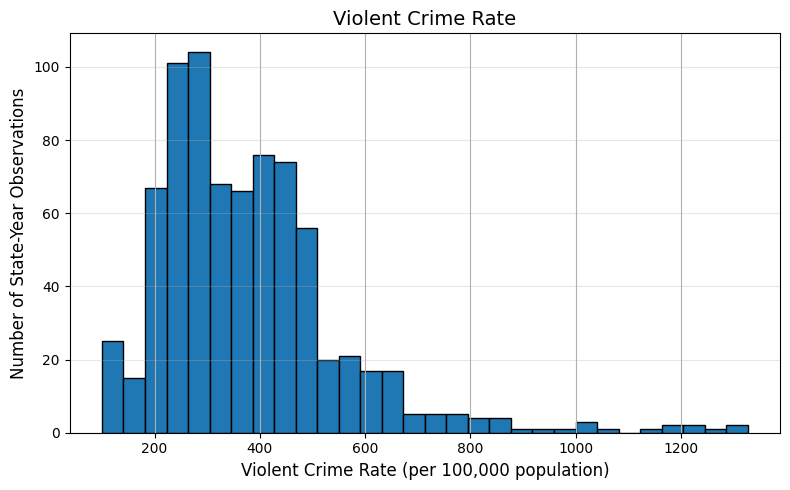

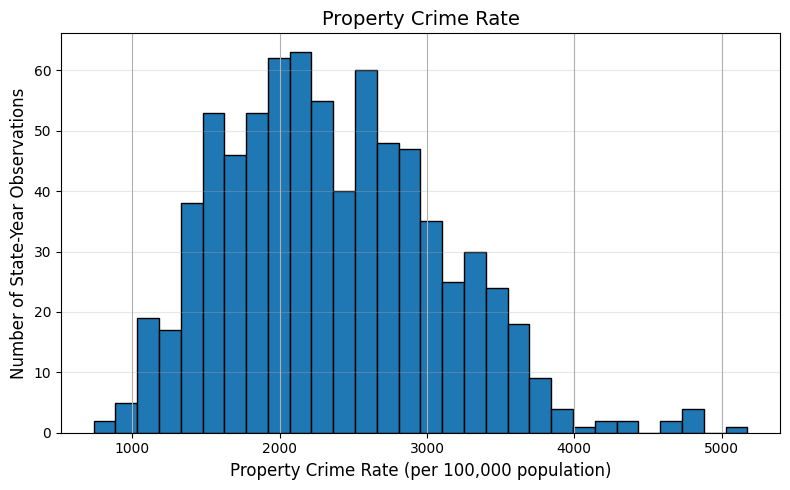

In [42]:
#Crime Variable Distributions

import matplotlib.pyplot as plt

crime_columns = [
    "violent_crime_rate",
    "property_crime_rate"
]

for col in crime_columns:

    plt.figure(figsize=(8,5))

    panel[col].hist(
        bins=30,
        edgecolor="black"
    )

    plt.title(
        col.replace("_", " ").title(),
        fontsize=14
    )

    if col == "violent_crime_rate":
        plt.xlabel(
            "Violent Crime Rate (per 100,000 population)",
            fontsize=12
        )
    else:
        plt.xlabel(
            "Property Crime Rate (per 100,000 population)",
            fontsize=12
        )

    plt.ylabel(
        "Number of State-Year Observations",
        fontsize=12
    )

    plt.grid(axis="y", alpha=0.3)

    plt.tight_layout()

    plt.show()

1. Violent Crime Rate Histogram
Most state-year observations have violent crime rates between 200 and 450 per 100,000 people.
The distribution is right-skewed, with a small number of state-years having much higher violent crime rates (above 800).
This suggests that extremely high violent crime rates are relatively uncommon.
2. Property Crime Rate Histogram
Property crime rates are more spread out than violent crime rates.
Most observations fall between 1,500 and 3,000 per 100,000 people.
A few state-years have exceptionally high property crime rates (around 4,500–5,000).

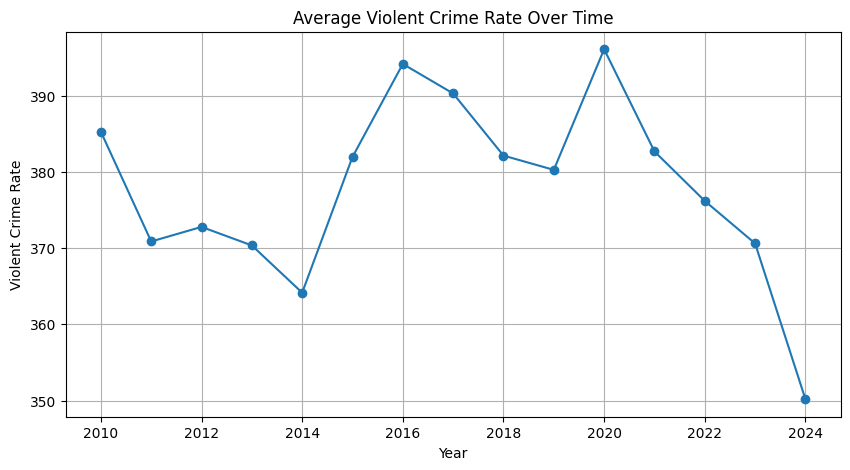

In [43]:
# Crime trend over time

crime_trend = (
    panel
    .groupby("year")["violent_crime_rate"]
    .mean()
)

plt.figure(figsize=(10,5))

plt.plot(
    crime_trend.index,
    crime_trend.values,
    marker="o"
)

plt.title("Average Violent Crime Rate Over Time")

plt.xlabel("Year")

plt.ylabel("Violent Crime Rate")

plt.grid(True)

plt.show()

Violent Crime Trend
Violent crime generally declined from 2010 to 2014.
There was an increase around 2015–2016.
Rates rose again around 2020, then declined through 2024.
The noticeable drop in 2024 should be mentioned as a possible result of using the most recent available estimates and differences in reporting or data completeness.

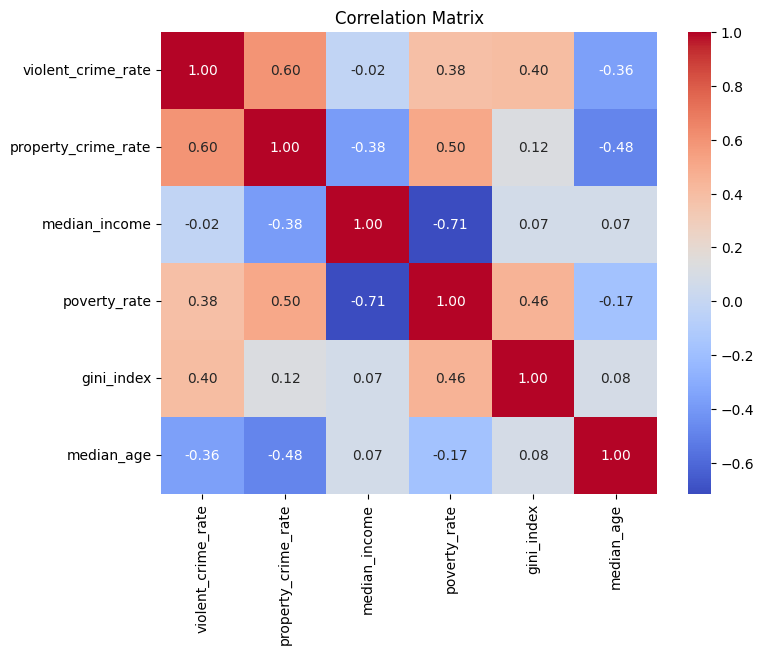

In [44]:
# Correlation Matrix

import seaborn as sns

corr_cols = [
    "violent_crime_rate",
    "property_crime_rate",
    "median_income",
    "poverty_rate",
    "gini_index",
    "median_age"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    panel[corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

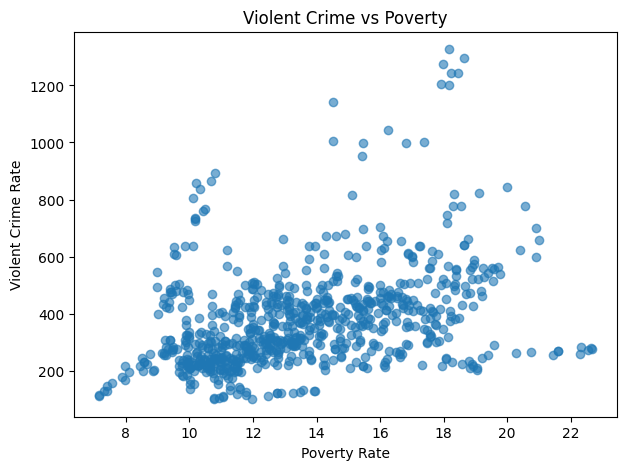

In [45]:
# Poverty vs Violent Crime

plt.figure(figsize=(7,5))

plt.scatter(
    panel["poverty_rate"],
    panel["violent_crime_rate"],
    alpha=0.6
)

plt.xlabel("Poverty Rate")

plt.ylabel("Violent Crime Rate")

plt.title("Violent Crime vs Poverty")

plt.show()

Violent Crime vs. Poverty

The scatterplot shows an upward trend:

Higher poverty rates are generally associated with higher violent crime rates.
The relationship is positive but not perfect, indicating that other factors also influence crime.

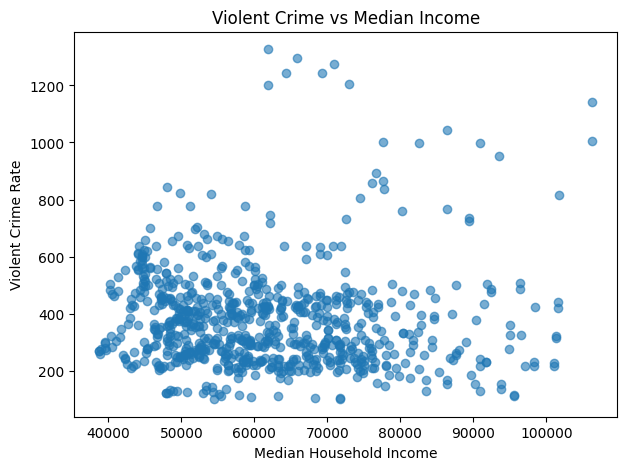

In [46]:
# Median Income vs Violent Crime
plt.figure(figsize=(7,5))

plt.scatter(
    panel["median_income"],
    panel["violent_crime_rate"],
    alpha=0.6
)

plt.xlabel("Median Household Income")

plt.ylabel("Violent Crime Rate")

plt.title("Violent Crime vs Median Income")

plt.show()

Violent Crime vs. Median Income

There is no strong linear relationship.

Higher-income states often have lower violent crime rates.
However, there is considerable variation, so income alone does not explain violent crime.

# Task 6: Feature Engineering

## Objective

The integrated dataset was transformed into a modeling-ready dataset by creating
additional features that may improve predictive performance.

The feature engineering process includes:

- Creating arrest-rate variables
- Creating lagged crime variables
- Creating year-based features
- Encoding categorical variables
- Final data quality verification

In [47]:
# =====================================================
# Create Arrest Rate Features
# =====================================================

arrest_columns = [
    col for col in panel.columns
    if col.endswith("_arrests")
]

for col in arrest_columns:
    panel[col.replace("_arrests", "_arrest_rate")] = (
        panel[col] /
        panel["population"]
    ) * 100000

print("Created arrest-rate variables.")

display(panel.filter(like="_arrest_rate").head())

Created arrest-rate variables.


,aggravated_assault_arrest_rate,burglary_arrest_rate,homicide_arrest_rate,larceny_arrest_rate,motor_vehicle_theft_arrest_rate,property_crime_arrest_rate,rape_arrest_rate,robbery_arrest_rate,violent_crime_arrest_rate
0,291.957107,68.053311,3.500685,439.826030,39.207669,551.707914,12.322410,36.967231,344.747433
1,230.431299,57.607825,4.420744,427.845163,36.747437,528.278949,11.190009,31.083359,277.125411
2,179.787404,42.310973,2.190859,418.317228,27.796529,493.217236,11.775870,27.796529,221.550663
3,174.701157,35.808312,2.984026,469.441540,29.162072,543.364001,14.377580,30.111535,222.174297
4,171.359725,38.260841,2.577858,383.151119,27.678055,468.220437,11.803877,28.220762,213.962222


In [48]:
# =====================================================
# Lag Features
# =====================================================

panel = panel.sort_values(
    ["state_abbr", "year"]
)

panel["violent_crime_rate_lag1"] = (
    panel.groupby("state_abbr")["violent_crime_rate"]
    .shift(1)
)

panel["property_crime_rate_lag1"] = (
    panel.groupby("state_abbr")["property_crime_rate"]
    .shift(1)
)

panel["violent_crime_rate_lag1"] = (
    panel.groupby("state_abbr")["violent_crime_rate_lag1"]
    .transform(lambda x: x.bfill())
)

panel["property_crime_rate_lag1"] = (
    panel.groupby("state_abbr")["property_crime_rate_lag1"]
    .transform(lambda x: x.bfill())
)

display(
    panel[
        [
            "state_abbr",
            "year",
            "violent_crime_rate",
            "violent_crime_rate_lag1"
        ]
    ].head(15)
)

,state_abbr,year,violent_crime_rate,violent_crime_rate_lag1
0,AK,2010,635.304266,635.304266
1,AK,2011,610.062719,635.304266
2,AK,2012,604.129496,610.062719
3,AK,2013,638.717194,604.129496
4,AK,2014,635.509860,638.717194
5,AK,2015,730.775956,635.509860
6,AK,2016,804.561429,730.775956
7,AK,2017,856.734245,804.561429
8,AK,2018,891.668106,856.734245
9,AK,2019,865.045536,891.668106


In [49]:
# =====================================================
# Year Since 2010
# =====================================================

panel["years_since_2010"] = panel["year"] - 2010

display(
    panel[
        ["year", "years_since_2010"]
    ].head()
)

,year,years_since_2010
0,2010,0
1,2011,1
2,2012,2
3,2013,3
4,2014,4


In [50]:
# =====================================================
# Census Region
# =====================================================

region_map = {

"CT":"Northeast","ME":"Northeast","MA":"Northeast",
"NH":"Northeast","RI":"Northeast","VT":"Northeast",
"NJ":"Northeast","NY":"Northeast","PA":"Northeast",

"IL":"Midwest","IN":"Midwest","MI":"Midwest",
"OH":"Midwest","WI":"Midwest","IA":"Midwest",
"KS":"Midwest","MN":"Midwest","MO":"Midwest",
"NE":"Midwest","ND":"Midwest","SD":"Midwest",

"DE":"South","FL":"South","GA":"South",
"MD":"South","NC":"South","SC":"South",
"VA":"South","DC":"South","WV":"South",
"AL":"South","KY":"South","MS":"South",
"TN":"South","AR":"South","LA":"South",
"OK":"South","TX":"South",

"AZ":"West","CO":"West","ID":"West",
"MT":"West","NV":"West","NM":"West",
"UT":"West","WY":"West","AK":"West",
"CA":"West","HI":"West","OR":"West",
"WA":"West"

}

panel["region"] = panel["state_abbr"].map(region_map)

display(
    panel[
        ["state_abbr","region"]
    ].drop_duplicates().head(20)
)

,state_abbr,region
0,AK,West
15,AL,South
30,AR,South
45,AZ,West
60,CA,West
75,CO,West
90,CT,Northeast
105,DC,South
120,DE,South
135,FL,South


In [51]:
# =====================================================
# One-Hot Encode Region
# =====================================================

region_dummies = pd.get_dummies(
    panel["region"],
    prefix="region",
    drop_first=True
)

panel = pd.concat(
    [panel, region_dummies],
    axis=1
)

display(region_dummies.head())

,region_Northeast,region_South,region_West
0,False,False,True
1,False,False,True
2,False,False,True
3,False,False,True
4,False,False,True


In [52]:
# =====================================================
# Final Dataset Check
# =====================================================

print("Final Dataset Shape:", panel.shape)

print("\nRemaining Missing Values:")

display(
    panel.isna()
    .sum()
    .sort_values(ascending=False)
    .loc[lambda x: x > 0]
)

display(panel.head())

Final Dataset Shape: (765, 58)

Remaining Missing Values:


,0
state_fips_y,51


,year,state_abbr,state_name,population,violent_crime,homicide,rape_legacy,rape_revised,robbery,aggravated_assault,property_crime,burglary,larceny,motor_vehicle_theft,state_fips_x,rape,rape_definition_revised,nibrs_gap_2021,violent_crime_rate,homicide_rate,rape_rate,robbery_rate,aggravated_assault_rate,property_crime_rate,burglary_rate,larceny_rate,motor_vehicle_theft_rate,merge_key,state_fips_y,median_income,poverty_rate,gini_index,median_age,aggravated_assault_arrests,burglary_arrests,homicide_arrests,larceny_arrests,motor_vehicle_theft_arrests,property_crime_arrests,rape_arrests,robbery_arrests,violent_crime_arrests,aggravated_assault_arrest_rate,burglary_arrest_rate,homicide_arrest_rate,larceny_arrest_rate,motor_vehicle_theft_arrest_rate,property_crime_arrest_rate,rape_arrest_rate,robbery_arrest_rate,violent_crime_arrest_rate,violent_crime_rate_lag1,property_crime_rate_lag1,years_since_2010,region,region_Northeast,region_South,region_West
0,2010,AK,Alaska,714146,4537,31,533.0,925.0,594,3379,20259,3105,15535,1619,02,533.0,0,0,635.304266,4.340849,74.634599,83.176269,473.152549,2836.814881,434.785044,2175.325494,226.704343,AK_2010,NaN,69014.0,9.510698,0.4103,33.8,2085.0,486.0,25.0,3141.0,280.0,3940.0,88.0,264.0,2462.0,291.957107,68.053311,3.500685,439.826030,39.207669,551.707914,12.322410,36.967231,344.747433,635.304266,2836.814881,0,West,False,False,True
1,2011,AK,Alaska,723860,4416,30,436.0,925.0,576,3374,19094,2852,14854,1388,02,436.0,0,0,610.062719,4.144448,60.232642,79.573398,466.112232,2637.802890,393.998840,2052.054265,191.749786,AK_2011,02,69014.0,9.510698,0.4103,33.8,1668.0,417.0,32.0,3097.0,266.0,3824.0,81.0,225.0,2006.0,230.431299,57.607825,4.420744,427.845163,36.747437,528.278949,11.190009,31.083359,277.125411,635.304266,2836.814881,1,West,False,False,True
2,2012,AK,Alaska,730307,4412,30,583.0,925.0,630,3169,20037,2950,15565,1522,02,583.0,0,0,604.129496,4.107861,79.829442,86.265091,433.927102,2743.640688,403.939713,2131.295469,208.405506,AK_2012,02,69917.0,9.590023,0.4132,33.8,1313.0,309.0,16.0,3055.0,203.0,3602.0,86.0,203.0,1618.0,179.787404,42.310973,2.190859,418.317228,27.796529,493.217236,11.775870,27.796529,221.550663,610.062719,2637.802890,2,West,False,False,True
3,2013,AK,Alaska,737259,4709,34,657.0,925.0,623,3127,21211,2917,16599,1695,02,925.0,1,0,638.717194,4.611676,125.464728,84.502190,424.138600,2877.007944,395.654716,2251.447592,229.905637,AK_2013,02,70760.0,9.873573,0.4143,33.6,1288.0,264.0,22.0,3461.0,215.0,4006.0,106.0,222.0,1638.0,174.701157,35.808312,2.984026,469.441540,29.162072,543.364001,14.377580,30.111535,222.174297,604.129496,2743.640688,3,West,False,False,True
4,2014,AK,Alaska,737046,4684,41,553.0,771.0,629,3243,20334,3150,15445,1739,02,771.0,1,0,635.509860,5.562746,104.606768,85.340671,439.999674,2758.850872,427.381737,2095.527281,235.941854,AK_2014,02,71829.0,10.104396,0.4146,33.4,1263.0,282.0,19.0,2824.0,204.0,3451.0,87.0,208.0,1577.0,171.359725,38.260841,2.577858,383.151119,27.678055,468.220437,11.803877,28.220762,213.962222,638.717194,2877.007944,4,West,False,False,True


In [53]:
# =====================================================
# Save Modeling Dataset
# =====================================================

panel.to_csv(
    "final_crime_panel.csv",
    index=False
)

print("Saved: final_crime_panel.csv")

Saved: final_crime_panel.csv


# Task 7: Machine Learning Modeling

## Objective

The final integrated dataset was used to predict violent crime rates across
U.S. states using multiple supervised machine learning algorithms.

Four regression models were evaluated:

- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor

Model performance was evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [54]:
# ======================================================
# Machine Learning Libraries
# ======================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [55]:
# ======================================================
# Model B - Clean Feature Selection
# Remove violent-crime arrest-rate leakage
# ======================================================

features_b = [

    "median_income",
    "poverty_rate",
    "gini_index",
    "median_age",
    "years_since_2010"

]

# Add arrest-rate variables first
features_b += [

    col
    for col in panel.columns
    if col.endswith("_arrest_rate")

]

# Arrest rates for violent crimes are downstream of the target
leaky = [

    "violent_crime_arrest_rate",
    "aggravated_assault_arrest_rate",
    "homicide_arrest_rate",
    "robbery_arrest_rate",
    "rape_arrest_rate"

]

# Keep socioeconomic variables and non-violent arrest-rate variables
features_clean = [

    col
    for col in features_b
    if col not in leaky

]

X_b = panel[features_clean]

y_b = panel["violent_crime_rate"]

print("Original predictors:", len(features_b))
print("Clean predictors:", len(features_clean))
print("Removed predictors:", [col for col in leaky if col in features_b])

display(X_b.head())

Original predictors: 14
Clean predictors: 9
Removed predictors: ['violent_crime_arrest_rate', 'aggravated_assault_arrest_rate', 'homicide_arrest_rate', 'robbery_arrest_rate', 'rape_arrest_rate']


,median_income,poverty_rate,gini_index,median_age,years_since_2010,burglary_arrest_rate,larceny_arrest_rate,motor_vehicle_theft_arrest_rate,property_crime_arrest_rate
0,69014.0,9.510698,0.4103,33.8,0,68.053311,439.826030,39.207669,551.707914
1,69014.0,9.510698,0.4103,33.8,1,57.607825,427.845163,36.747437,528.278949
2,69917.0,9.590023,0.4132,33.8,2,42.310973,418.317228,27.796529,493.217236
3,70760.0,9.873573,0.4143,33.6,3,35.808312,469.441540,29.162072,543.364001
4,71829.0,10.104396,0.4146,33.4,4,38.260841,383.151119,27.678055,468.220437


In [56]:
# ======================================================
# Time-Aware Train/Test Split
# ======================================================

train = panel[panel["year"] <= 2021]
test = panel[panel["year"] >= 2022]

X_train_b = train[features_clean]
y_train_b = train["violent_crime_rate"]

X_test_b = test[features_clean]
y_test_b = test["violent_crime_rate"]

print(
    "Train years:",
    train["year"].min(),
    "to",
    train["year"].max()
)

print(
    "Test years:",
    test["year"].min(),
    "to",
    test["year"].max()
)

print("Training rows:", len(train))
print("Testing rows:", len(test))

Train years: 2010 to 2021
Test years: 2022 to 2024
Training rows: 612
Testing rows: 153


In [57]:
# ======================================================
# Train Models
# ======================================================

models_b = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )

}

results_b = []

predictions_b = {}

for name, model in models_b.items():

    model.fit(
        X_train_b,
        y_train_b
    )

    train_pred = model.predict(X_train_b)
    test_pred = model.predict(X_test_b)

    predictions_b[name] = test_pred

    train_r2 = r2_score(
        y_train_b,
        train_pred
    )

    test_r2 = r2_score(
        y_test_b,
        test_pred
    )

    results_b.append({

        "Model": name,

        "Train R²": train_r2,

        "Test R²": test_r2,

        "R² Gap": train_r2 - test_r2,

        "MAE": mean_absolute_error(
            y_test_b,
            test_pred
        ),

        "RMSE": np.sqrt(
            mean_squared_error(
                y_test_b,
                test_pred
            )
        )

    })

results_b = pd.DataFrame(results_b)

display(results_b.round(3))

,Model,Train R²,Test R²,R² Gap,MAE,RMSE
0,Linear Regression,0.433,0.216,0.217,123.883,149.805
1,Decision Tree,1.000,-0.087,1.087,104.040,176.416
2,Random Forest,0.971,0.397,0.575,83.118,131.416
3,Gradient Boosting,0.898,0.341,0.557,90.002,137.298


In [58]:
# ======================================================
# Clean Results and Add One Mean Baseline
# ======================================================

# Remove any old baseline rows
results_b = results_b[
    results_b["Model"] != "Mean Baseline"
].copy()

# Remove the old R² column if it still exists
if "R²" in results_b.columns:
    results_b = results_b.drop(columns=["R²"])

# Mean baseline predictions
mean_prediction = np.full(
    len(y_test_b),
    y_train_b.mean()
)

baseline_row = pd.DataFrame([{
    "Model": "Mean Baseline",
    "Train R²": np.nan,
    "Test R²": r2_score(
        y_test_b,
        mean_prediction
    ),
    "R² Gap": np.nan,
    "MAE": mean_absolute_error(
        y_test_b,
        mean_prediction
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            y_test_b,
            mean_prediction
        )
    )
}])

# Combine baseline with model results
results_with_baseline_b = pd.concat(
    [baseline_row, results_b],
    ignore_index=True
)

# Keep only the correct columns
results_with_baseline_b = results_with_baseline_b[
    [
        "Model",
        "Train R²",
        "Test R²",
        "R² Gap",
        "MAE",
        "RMSE"
    ]
]

display(results_with_baseline_b.round(3))

,Model,Train R²,Test R²,R² Gap,MAE,RMSE
0,Mean Baseline,NaN,-0.008,NaN,129.131,169.861
1,Linear Regression,0.433,0.216,0.217,123.883,149.805
2,Decision Tree,1.000,-0.087,1.087,104.040,176.416
3,Random Forest,0.971,0.397,0.575,83.118,131.416
4,Gradient Boosting,0.898,0.341,0.557,90.002,137.298


In [59]:
# ======================================================
# Best Model
# ======================================================

best_model_b = (
    results_b
    .sort_values("Test R²", ascending=False)
    .reset_index(drop=True)
)

display(best_model_b.round(3))

print(
    "Best explanatory model:",
    best_model_b.iloc[0]["Model"]
)

,Model,Train R²,Test R²,R² Gap,MAE,RMSE
0,Random Forest,0.971,0.397,0.575,83.118,131.416
1,Gradient Boosting,0.898,0.341,0.557,90.002,137.298
2,Linear Regression,0.433,0.216,0.217,123.883,149.805
3,Decision Tree,1.000,-0.087,1.087,104.040,176.416


Best explanatory model: Random Forest


The Random Forest model performed best, achieving the highest Test R² (0.397) and the lowest MAE (83.118) and RMSE (131.416) among the evaluated models. Although it showed some overfitting, it generalized better than the other models on the unseen test data. Therefore, Random Forest was selected as the final model and saved for future predictions.

In [60]:
# ======================================================
# Feature Importance
# ======================================================

rf_b = models_b["Random Forest"]

importance_b = pd.DataFrame({

    "Feature": features_clean,

    "Importance": rf_b.feature_importances_

})

importance_b = importance_b.sort_values(

    "Importance",

    ascending=False

).reset_index(drop=True)

display(importance_b)

,Feature,Importance
0,gini_index,0.449846
1,poverty_rate,0.148784
2,median_age,0.109579
3,motor_vehicle_theft_arrest_rate,0.090454
4,burglary_arrest_rate,0.080428
5,median_income,0.057550
6,larceny_arrest_rate,0.025659
7,years_since_2010,0.020750
8,property_crime_arrest_rate,0.016950


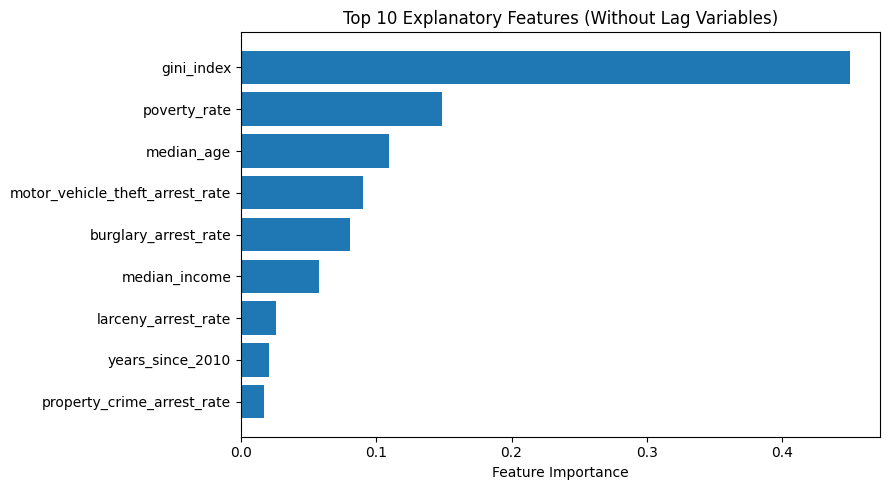

In [61]:
import matplotlib.pyplot as plt

top = importance_b.head(10)

plt.figure(figsize=(9,5))

plt.barh(

    top["Feature"],

    top["Importance"]

)

plt.title(
    "Top 10 Explanatory Features (Without Lag Variables)"
)

plt.xlabel(
    "Feature Importance"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

In [62]:
# ======================================================
# Cross-Validation and Overfitting Check
# ======================================================

from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor

# Sort all observations chronologically
panel_sorted = panel.sort_values(["year"])

Xall = panel_sorted[features_clean]
yall = panel_sorted["violent_crime_rate"]

# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

scores = cross_val_score(
    GradientBoostingRegressor(random_state=42),
    Xall,
    yall,
    cv=tscv,
    scoring="r2"
)

print("Gradient Boosting CV R² per fold:", np.round(scores, 3))
print("Mean CV R²:", round(scores.mean(), 3))

# Fit Gradient Boosting on the chronological training set
gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train_b, y_train_b)

train_r2 = gb.score(X_train_b, y_train_b)
test_r2 = gb.score(X_test_b, y_test_b)
r2_gap = train_r2 - test_r2

print("\nTrain R²:", round(train_r2, 3))
print("Test R²:", round(test_r2, 3))
print("R² Gap:", round(r2_gap, 3))

Gradient Boosting CV R² per fold: [0.805 0.61  0.584 0.289 0.341]
Mean CV R²: 0.526

Train R²: 0.898
Test R²: 0.341
R² Gap: 0.557


In [63]:
# ============================================================
# Week 10: Tune, Compare, Select, Save, and Deploy Final Model
# ============================================================

import joblib
import sklearn
import numpy as np
import pandas as pd

from datetime import date

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
)


# ============================================================
# 1. Tune Gradient Boosting with time-aware cross-validation
# ============================================================

tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    "n_estimators": [200, 400],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3],
}

search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=tscv,
    scoring="r2",
    n_jobs=-1,
)

search.fit(X_train_b, y_train_b)

tuned_gb = search.best_estimator_

print("Best Gradient Boosting parameters:", search.best_params_)
print("Best CV R²:", round(search.best_score_, 3))


# ============================================================
# 2. Compare the top models
# ============================================================

candidate_models = {
    "Random Forest": models_b["Random Forest"],
    "Tuned Gradient Boosting": tuned_gb,
}

comparison_rows = []

for model_name, model in candidate_models.items():

    train_predictions = model.predict(X_train_b)
    test_predictions = model.predict(X_test_b)

    train_r2 = r2_score(y_train_b, train_predictions)
    test_r2 = r2_score(y_test_b, test_predictions)
    mae = mean_absolute_error(y_test_b, test_predictions)
    rmse = np.sqrt(
        mean_squared_error(y_test_b, test_predictions)
    )

    comparison_rows.append({
        "Model": model_name,
        "Train R²": train_r2,
        "Test R²": test_r2,
        "R² Gap": train_r2 - test_r2,
        "MAE": mae,
        "RMSE": rmse,
    })

final_comparison = pd.DataFrame(comparison_rows)

final_comparison = (
    final_comparison
    .sort_values("Test R²", ascending=False)
    .reset_index(drop=True)
)

display(final_comparison.round(3))


# ============================================================
# 3. Select the final model
# Rule: highest held-out test R²
# ============================================================

selected_model_name = final_comparison.iloc[0]["Model"]
best_model = candidate_models[selected_model_name]

print("Selection rule: highest held-out test R²")
print("Selected final model:", selected_model_name)


# ============================================================
# 4. Final held-out test evaluation
# ============================================================

final_predictions = best_model.predict(X_test_b)

final_metrics = {
    "r2": float(
        r2_score(y_test_b, final_predictions)
    ),
    "mae": float(
        mean_absolute_error(y_test_b, final_predictions)
    ),
    "rmse": float(
        np.sqrt(
            mean_squared_error(y_test_b, final_predictions)
        )
    ),
}

print("Final Test R²:", round(final_metrics["r2"], 3))
print("Final Test MAE:", round(final_metrics["mae"], 3))
print("Final Test RMSE:", round(final_metrics["rmse"], 3))


# ============================================================
# 5. Create feature statistics from training data only
# ============================================================

features_to_save = features_clean

feature_stats = {}

for col in features_to_save:

    series = X_train_b[col].astype(float)

    feature_stats[col] = {
        "min": float(series.min()),
        "max": float(series.max()),
        "median": float(series.median()),
    }


# ============================================================
# 6. Bundle and save the selected model
# ============================================================

bundle = {
    "model": best_model,
    "model_name": selected_model_name,
    "features": features_to_save,
    "target": "violent_crime_rate",
    "selection_rule": "Highest held-out test R²",
    "metrics": final_metrics,
    "feature_stats": feature_stats,
    "training_years": {
        "start": int(train["year"].min()),
        "end": int(train["year"].max()),
    },
    "test_years": {
        "start": int(test["year"].min()),
        "end": int(test["year"].max()),
    },
    "gradient_boosting_best_params": search.best_params_,
    "gradient_boosting_best_cv_r2": float(search.best_score_),
    "sklearn_version": sklearn.__version__,
    "saved_on": str(date.today()),
}

output_file = "violent_crime_model.joblib"

joblib.dump(bundle, output_file)

print("\nModel saved successfully!")
print("Model:", selected_model_name)
print("Number of features:", len(features_to_save))
print("Test R²:", round(final_metrics["r2"], 3))
print("Test MAE:", round(final_metrics["mae"], 3))
print("Test RMSE:", round(final_metrics["rmse"], 3))
print("scikit-learn version:", sklearn.__version__)
print("Saved file:", output_file)


# ============================================================
# 7. Prediction function
# ============================================================

def predict_violent_crime_rate(new_rows):
    """
    Predict violent crime rates for new observations.

    Parameters
    ----------
    new_rows : pandas.DataFrame
        DataFrame containing the required predictor columns.

    Returns
    -------
    numpy.ndarray
        Predicted violent crime rates.
    """

    saved_bundle = joblib.load(
        "violent_crime_model.joblib"
    )

    required_features = saved_bundle["features"]

    missing_features = [
        feature
        for feature in required_features
        if feature not in new_rows.columns
    ]

    if missing_features:
        raise ValueError(
            f"Missing required features: {missing_features}"
        )

    prediction_data = (
        new_rows[required_features]
        .copy()
        .astype(float)
    )

    return saved_bundle["model"].predict(
        prediction_data
    )


# ============================================================
# 8. Test the prediction function
# ============================================================

sample_row = X_test_b.iloc[[0]].copy()

sample_prediction = predict_violent_crime_rate(
    sample_row
)

print(
    "\nSample prediction:",
    round(float(sample_prediction[0]), 3)
)

Best Gradient Boosting parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}
Best CV R²: -1.323


,Model,Train R²,Test R²,R² Gap,MAE,RMSE
0,Random Forest,0.971,0.397,0.575,83.118,131.416
1,Tuned Gradient Boosting,0.877,0.328,0.550,92.153,138.711


Selection rule: highest held-out test R²
Selected final model: Random Forest
Final Test R²: 0.397
Final Test MAE: 83.118
Final Test RMSE: 131.416

Model saved successfully!
Model: Random Forest
Number of features: 9
Test R²: 0.397
Test MAE: 83.118
Test RMSE: 131.416
scikit-learn version: 1.6.1
Saved file: violent_crime_model.joblib

Sample prediction: 448.495


The Random Forest model was selected as the final model because it achieved the highest held-out test R² of 0.397. It also produced the lowest MAE and RMSE among the final candidate models. Although the model’s training R² was substantially higher than its test R², indicating some overfitting, it still generalized better to the 2022–2024 test period than the tuned Gradient Boosting model. The selected Random Forest model was saved with its required features, performance metrics, feature statistics, and scikit-learn version for future deployment.